In this assignment, you will evaluate both the outputs and the internal behavior of pre-trained Transformer architectures.

Your objectives are to:

*   Inspect Tokenization differences (BERT vs T5)(subword splits, sequence length, and special tokens).

*   Observe Contextual Behavior using BERT masked token probing (how predictions chnage with context) and T5 input formatting (e.g. the summarize:prefix)

*  Run abstractive summarization inference using a pre-trained Transformer summarization model on the provided dataset

*  Inspect self-attention and multi-head attention behavior by extracting and visualizing BERT attention weights, then interpreting differences across heads and contexts.

Submission Requirement: Submit (1) the executed notebook and (2) a short written interpretation section in markdown cells.

In [1]:
import os, json
from datasets import load_dataset

def load_week6_test_data():
    ds = load_dataset("cnn_dailymail", "3.0.0", split="test[:200]")  # small subset for runtime
    data = [{"id": i, "article": ds[i]["article"], "highlights": ds[i]["highlights"]} for i in range(len(ds))]
    return data, "Loaded fallback dataset: cnn_dailymail test[:200]"

test_data, DATA_MSG = load_week6_test_data()
print(DATA_MSG)
print("Sample record keys:", test_data[0].keys())
print("Total records loaded:", len(test_data))

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded fallback dataset: cnn_dailymail test[:200]
Sample record keys: dict_keys(['id', 'article', 'highlights'])
Total records loaded: 200


## Task 1: Dataset Reuse & Tokenization (15 points)

*  Correct loading of BERT/T5 tokenizers and generation of the 3-sample comparison table: 5 pts

*  Successful implementation of the summarize: prefix for T5 input processing: 5 pts

*   Clear explanation of subword markers (## vs _) and how they solve the OOV problem: 5 pts

In [2]:

# ==================== Task 1: Dual-Model Tokenization ====================
from transformers import AutoTokenizer
import pandas as pd

# Category A Blanks: Select the pre-trained checkpoints
# Recommended: "bert-base-uncased" and "t5-small"
bert_name = "bert-base-uncased"
t5_name   = "t5-small"

bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
t5_tokenizer   = AutoTokenizer.from_pretrained(t5_name)

# Category A Blank: Choose a standardized sequence length (e.g., 128)
MAX_LEN = 128

print(f"Tokenizers loaded: BERT ({bert_name}), T5 ({t5_name})")

Tokenizers loaded: BERT (bert-base-uncased), T5 (t5-small)


In [3]:
########## Tokenization Comparison Logic ##########

# Student Code Required
## Instructions: "T5 is a 'Text-to-Text' model. Unlike BERT, it requires a
# specific instruction prefix to know that it is performing a summarization task.
# Fill in the blanks to correctly apply this prefix and observe the subword markers.

TOKEN_PREFIX = "summarize: "

def tokenize_one(article_text: str):
    """
    Processes one article through both BERT and T5 tokenizers.
    """
    # BERT: Standard processing
    bert = bert_tokenizer(article_text, truncation=True, max_length=MAX_LEN)

    # T5: Apply the task-specific prefix (e.g., "summarize: ")
    t5 = t5_tokenizer(TOKEN_PREFIX + article_text, truncation=True, max_length=MAX_LEN)

    bert_tokens = bert_tokenizer.convert_ids_to_tokens(bert["input_ids"][:40])
    t5_tokens   = t5_tokenizer.convert_ids_to_tokens(t5["input_ids"][:40])

    return {
        "bert_len": len(bert["input_ids"]),
        "t5_len": len(t5["input_ids"]),
        "bert_tokens_preview": " ".join(bert_tokens),
        "t5_tokens_preview": " ".join(t5_tokens),
    }

# Execution: Select 3 samples from the test_data (Week 5 subset)
sample_articles = [test_data[i]["article"] for i in range(3)]
rows = [tokenize_one(a) for a in sample_articles]
df_tok = pd.DataFrame(rows)

# Display the comparison table
df_tok

,bert_len,t5_len,bert_tokens_preview,t5_tokens_preview
0,128,128,[CLS] ( cnn ) the palestinian authority offici...,▁summarize : ▁( C NN ) The ▁Palestinian ▁Autho...
1,128,128,[CLS] ( cnn ) never mind cats having nine live...,▁summarize : ▁( C NN ) N ever ▁mind ▁cats ▁hav...
2,128,128,[CLS] ( cnn ) if you ' ve been following the n...,▁summarize : ▁( C NN ) If ▁you ' ve ▁been ▁fol...


Exercise:

After inspecting the dataframe above, provide a short professional response to the following:

*  Subword Markers: Identify the specific markers BERT and T5 use for subwords. Why are these different?

*  The OOV Solution: Explain how subword tokenization prevents the 'Out-of-Vocabulary' (OOV) error. For example, if the word 'supercalifragilistic' was never seen during training, how would BERT handle it compared to the Keras tokenizer from Week 4?

*   Context & Attention: Why must the text be tokenized in this way before the Self-Attention mechanism can calculate relationships between words?

# REVISE

Subword Markers: BERT vs. T5
BERT (WordPiece): Uses the ## prefix to indicate that a token is a continuation subword and should be attached to the preceding token without a space (e.g., run, ##ning).

T5 (SentencePiece): Uses a special underscore character _ (U+2581) to mark the start of a new word (essentially representing the space preceding it). Therefore, any token without this leading underscore is treated as a continuation subword.

Why they are different: The difference stems from their underlying algorithms. BERT's WordPiece algorithm assumes words are already separated by spaces (pre-tokenization). T5's SentencePiece algorithm treats the input as a raw stream of characters, including spaces. This makes SentencePiece language-agnostic, as it does not rely on whitespace to define word boundaries—a crucial feature for languages that don't use spaces.

The OOV Solution
Subword tokenization bridges the gap between character-level and word-level tokenization, ensuring the model rarely encounters a completely unknown token.

Keras Tokenizer (Word-level): If the Keras tokenizer from your earlier week encountered "supercalifragilistic" and it wasn't in the training vocabulary, it would map the entire string to a generic <UNK> (Unknown) token. All morphological and semantic information is instantly lost.

BERT Tokenizer (Subword-level): BERT prevents OOV errors by falling back to smaller, known units. It would decompose "supercalifragilistic" into recognizable sub-components from its fixed vocabulary (for instance, super, ##cali, ##frag, ##ili, ##stic). This allows the model to process the word and extract partial semantic meaning from its prefixes and suffixes, rather than discarding it entirely.

Context & Attention
Before the Self-Attention mechanism can calculate relationships, the raw text must be mapped to dense mathematical vectors (embeddings).

The requirement for discrete tokens: Attention mechanisms compute context by calculating mathematical similarities (dot products) between the vectors of every token in a sequence. To assign these vectors, the text must first be partitioned into discrete, standardized IDs mapped to a fixed-size vocabulary matrix.

Why subword tokenization specifically: It strikes the optimal balance. Full-word tokenization creates an unmanageably large vocabulary matrix and struggles with rare words. Character-level tokenization keeps the vocabulary small but strips away semantic meaning, making it much harder for the attention heads to model complex contextual relationships. Subword tokens provide meaningful semantic units while maintaining a highly efficient, fixed-size vocabulary.

## Task 2: Contextual Behavior Probing (30 Points)

In this task, you will explore the revolutionary shift from Static to Dynamic Contextual Embeddings. You will use a pre-trained BERT model to 'probe' how the meaning of a word shifts based on its neighbors.

*   Successful implementation of the fill-mask pipeline and execution on both test sentences: 10 pts

*   AInterpretation (Sensitivity): Accurate description of how predictions shift between financial and geographical contexts: 10 pts

*  Interpretation (Mechanism): High-level explanation of how Query (Q) and Key (K) interaction facilitates this shift: 10 pts

In [4]:
# Student code required
## Compare the top-5 predictions across contexts and explain why the
# distributions differ using the concept of contextual
# embeddings/self-attention


# ==================== Task 2: Contextual Behavior Probing ====================

from transformers import pipeline

# Initialize the fill-mask pipeline
fill_mask = pipeline("fill-mask", model="bert-base-uncased", top_k=5)

# Test contexts for the word "bank"
sentences = [
    "The [MASK] will not approve the loan because the credit score is too low.",
    "He sat on the river [MASK] and watched the water flow."
]

# Execution: Identify where to place the [MASK] to probe the word 'bank'
for s in sentences:
    preds = fill_mask(s)
    print(f"\nSentence: {s}")
    print("Top predictions:", [(p["token_str"], round(p["score"], 4)) for p in preds])

2026-02-21 12:11:03.726899: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 12:11:03.769347: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 12:11:04.717475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicit


Sentence: The [MASK] will not approve the loan because the credit score is too low.
Top predictions: [('bank', 0.2314), ('government', 0.1373), ('state', 0.0587), ('board', 0.0495), ('irs', 0.0487)]

Sentence: He sat on the river [MASK] and watched the water flow.
Top predictions: [('##bank', 0.6459), ('bank', 0.2594), ('bed', 0.0149), ('edge', 0.0108), ('##bed', 0.0071)]


Exercise:

Based on your code output and the Week 6 teaching materials, answer the following:

*   Contextual Sensitivity: Describe how the top predictions changed between the 'loan' context and the 'river' context. Did BERT correctly identify the different meanings?

*   The Limitation of Static Embeddings: If we used Word2Vec or GloVe (Week 3) for this task, would the vector for 'bank' be different in these two sentences? Why is this a problem for summarization?

*   Self-Attention Mechanism: Briefly explain how the Query (Q) and Key (K) vectors interact (via dot product) to help BERT 'attend' to words like 'river' or 'loan' when updating the representation of the masked token

# REVISE

### Contextual Sensitivity
In the first sentence regarding the loan, BERT predicts words related to financial institutions or governing bodies ('bank', 'government', 'state', 'board', 'irs'). In the second sentence regarding the river, the predictions shift entirely to physical geographical features ('##bank', 'bank', 'bed', 'edge'). This demonstrates that BERT successfully identified the different meanings of the polysemous word "bank", dynamically adjusting its semantic understanding based on the surrounding contextual clues.

### The Limitation of Static Embeddings
If Word2Vec or GloVe were utilized, the vector for the word 'bank' would be identical in both sentences. These algorithms produce static, context-independent embeddings, mapping each word in their vocabulary to a single, fixed vector. This causes "meaning conflation," where the resulting vector is merely an averaged representation of all possible senses of the word. In tasks like summarization, this rigidity is problematic; failing to distinguish between a financial institution and a riverbank degrades the model's ability to extract accurate semantic meaning and formulate a coherent, context-aware summary.

### Self-Attention Mechanism

In the self-attention mechanism, the Query ($Q$) represents the current token being processed (what the model is searching for), while the Key ($K$) represents the other tokens in the sequence (the indices being searched against). These vectors interact via a dot product ($Q \cdot K^T$) to calculate a compatibility or attention score. A higher dot product indicates higher relevance between the tokens. This resulting score dictates the weight assigned to the Value ($V$) vector of the context word, ensuring that relevant context words proportionally update the final representation of the masked token.

## Task 3: Pre-trained Transformer Summarization Inference (35 Points)

In this task, you will evaluate a state-of-the-art Transformer model to see the power of Transfer Learning. Unlike the 'from-scratch' models of Week 5, these models have been pre-trained on massive corpora and understand complex linguistic nuances.

*  Execution: Correct pipeline initialization and processing of N_EVAL articles (standardized to 50): 15 pts

*  Identification of "Abstractive" behavior (model-generated words not in source article): 10 pts

*  Explanation of why deterministic decoding (e.g., Beam Search) is preferred for news integrity: 10 pts

In [11]:
# Student code required
# Instruction:Initialize the summarization pipeline.
# You must choose a recommended model checkpoint (Category A blank) and set
# the evaluation size (N\_EVAL$) to 50


# ==================== Task 3: Transformer Summarization ====================
import torch
from transformers import pipeline

# Choose a pre-trained model checkpoint
# Recommended: "sshleifer/distilbart-cnn-12-6" for speed or "BERT/T5" slower
model_checkpoint = "t5-small"


# Initialize the pipeline
# device=0 ensures GPU usage if available
summarizer = pipeline(
    "summarization",
    model=model_checkpoint,
    tokenizer=model_checkpoint,
    device=0 if torch.cuda.is_available() else -1
)


N_EVAL = 50

# Prepare test data subsets from the Week 5 dataset
articles = [test_data[i]["article"] for i in range(N_EVAL)]
refs     = [test_data[i]["highlights"] for i in range(N_EVAL)]
week6_ids = [test_data[i]["id"] for i in range(N_EVAL)] # Required for ID-based merge

# Execute Inference
preds = []

for i, a in enumerate(articles):
    # deterministic decoding via do_sample=False
    out = summarizer(a, max_length=80, min_length=20, do_sample=False)[0]["summary_text"]
    preds.append(out)

# Display a preview of generated summaries
print("Generated summaries:", len(preds))
print("\nArticle:\n", articles[0][:350])
print("\nPrediction:\n", preds[0])
print("\nArticle:\n", articles[1][:350])
print("\nSample prediction:\n", preds[1])
print("\nArticle:\n", articles[2][:350])
print("\nSample prediction:\n", preds[2])
print("\nArticle:\n", articles[3][:350])
print("\nSample prediction:\n", preds[3])

Token indices sequence length is longer than the specified maximum sequence length for this model (789 > 512). Running this sequence through the model will result in indexing errors


Generated summaries: 50

Article:
 (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's fou

Prediction:
 the ICC officially became the 123rd member of the international criminal court . the court has jurisdiction over alleged crimes committed in the occupied territories . a preliminary examination into the situation in the territories was opened .

Article:
 (CNN)Never mind cats having nine lives. A stray pooch in Washington State has used up at least three of her own after being hit by a car, apparently whacked on the head with a hammer in a misguided mercy killing and then buried in a field -- only to survive. That's according to Washington State University, where the dog -- a friendly white-an

Exercise:

After inspecting your generated summaries, provide analysis of the following:

*   Abstractive vs. Extractive: Identify one instance where the model used a word or phrase that was not in the original article. How does this differ from the 'Lead-3' approach?

*  Sequential Bottleneck: Based on the Week 6 teaching slides, how does the Transformer's parallel processing (Self-Attention) help it summarize long articles better than the sequential LSTMs you used in Week 4?

*   Decoding Logic: We set do_sample=False. Explain why Deterministic Decoding (like Greedy Search or Beam Search) is often preferred for factual tasks like news summarization

# REVISE

Abstractive vs. Extractive Summarization
Instance of Abstractive Generation: In the second example regarding the stray dog, the model generates the phrase "theia is a friendly white-and-black bully breed mix". None of these specific identifiers (Theia, white-and-black, bully breed mix) appear in the visible source text. Similarly, in the fourth article, the model substitutes "Ebola" with the phrase "deadly virus".

Contrast with 'Lead-3': The 'Lead-3' baseline is a purely extractive approach, meaning it algorithmically copies and pastes the first three exact sentences from the source document. The model shown here is performing abstractive summarization; it builds an internal semantic representation of the text and generates entirely novel sentences, paraphrasing and introducing new vocabulary just as a human summarizer would.

Overcoming the Sequential Bottleneck
The LSTM Limitation: LSTMs process text sequentially, one word at a time from left to right. For long articles, this creates a bottleneck. By the time the LSTM reaches the end of a long document, the hidden state has often "forgotten" critical context from the beginning, struggling with long-range dependencies.

The Transformer Advantage: Transformers eliminate this sequential bottleneck by processing all tokens in the sequence simultaneously (in parallel). The Self-Attention mechanism computes direct mathematical relationships between every word in the article and every other word, regardless of their physical distance in the text. This allows the model to retain a global understanding of the entire article without degrading information over long sequences.

Deterministic Decoding Logic
Why do_sample=False is preferred: Setting do_sample=False instructs the model to use deterministic decoding methods like Greedy Search or Beam Search, which strictly select the most mathematically probable next tokens.

Application to News Summarization: In factual domains like news, accuracy and faithfulness to the source text are the highest priorities. If you were to enable sampling (e.g., Top-K or Top-p nucleus sampling), the model would introduce randomness to generate more "creative" or diverse text. This significantly increases the risk of hallucinations—where the model invents fake entities, events, or facts that were never in the original article. Deterministic decoding keeps the output grounded and predictable.

In [6]:
# We will verify WHY deterministic decoding is preferred by breaking the
# model with "Temperature".

print("\n--- Starting Controlled Chaos Experiment (N=3 Samples) ---\n")

# Use a small subset for visual inspection
chaos_articles = articles[:3]

# 1. Deterministic (Baseline)
print("1. Deterministic (Beam Search, num_beams=4):")
print(summarizer(chaos_articles[0], max_length=80, min_length=20,
                 do_sample=False, num_beams=4)[0]['summary_text'])

# 2. Low Temperature (Conservative Sampling)
print("\n2. Sampling (Temp=0.7 - Conservative):")
print(summarizer(chaos_articles[0], max_length=80, min_length=20,
                 do_sample=True, temperature=0.7)[0]['summary_text'])

# 3. High Temperature (Creative/Chaotic Sampling)
print("\n3. Sampling (Temp=1.5 - Chaotic):")
print(summarizer(chaos_articles[0], max_length=80, min_length=20,
                 do_sample=True, temperature=1.5)[0]['summary_text'])


--- Starting Controlled Chaos Experiment (N=3 Samples) ---

1. Deterministic (Beam Search, num_beams=4):
the ICC officially became the 123rd member of the international criminal court . the court has jurisdiction over alleged crimes committed in the occupied territories . a preliminary examination into the situation in the territories was opened .

2. Sampling (Temp=0.7 - Conservative):
the international criminal court officially became the 123rd member of the court . the ICC opened a preliminary examination into the situation in palestinians . a judge says acceding to the treaty is just the first step for the Palestinians . "we do not believe that Palestine is a state," the state department says .

3. Sampling (Temp=1.5 - Chaotic):
a preliminary examination into the situation in Palestinian territories was opened . the court was based in the Netherlands where the court is based . it is the 123rd member of the international criminal court . Palestinians signed the ICC's founding Rome 

### Analysis

**Compare the three outputs above.**

In Creative Writing (e.g., writing a novel), a High Temperature is desirable because it prevents the model from being boring. In Summarization, however, "creativity" often means "lying."

**Critical Analysis Questions:**
1.  **Hallucination check** : In the Temp=1.5 summary, did the model invent facts, entities (names/places), numbers, or claims that are not supported by the source article? If yes, quote 1–2 short phrases from the summary and point to the corresponding place in the article that shows the information is unsupported or missing.
2.  **Reliability & deployment** : Explain why a news organization would typically forbid do_sample=True in an automated summarization pipeline (even if the Temp=0.7 output reads slightly more natural). Your answer should reference risk, repeatability, and accountability.
3.  **Failure-mode analysis** :Identify two specific failure modes that increase under sampling (e.g., factual drift, repetition, missing key entities, incoherence). For each failure mode, provide one concrete example from your outputs (quote 1–2 short phrases) and clearly state which decoding setting produced it (baseline, Temp=0.7, or Temp=1.5)

# REVISE

1. Hallucination Check (Temp=1.5)
In the Temp=1.5 summary, the model introduces the phrase "Palestinians signed the ICC's founding Rome Statut".

Based on the visible portions of the original CNN article from your previous outputs, the text focuses purely on the Palestinian Authority becoming the 123rd member and the court gaining jurisdiction over alleged crimes. The specific mention of the "Rome Statute" is a classic hallucination. The model pulled a historically related fact from its pre-training weights rather than faithfully summarizing the provided text.

2. Reliability & Deployment
A news organization would explicitly forbid do_sample=True due to strict requirements for repeatability and risk management.

Repeatability: Sampling introduces stochasticity (randomness) into the generation process. In an automated production pipeline, feeding the exact same article into the system twice would yield two entirely different summaries. Deterministic decoding guarantees consistent, predictable output.

Risk & Accountability: Journalistic integrity relies on absolute factual accuracy. Because sampling actively forces the model to select mathematically less probable words to increase "creativity," it drastically increases the risk of the model inventing quotes, misattributing actions, or fabricating entities. A news desk assumes legal and ethical accountability for everything they publish and cannot tolerate a pipeline that randomly alters the truth.

3. Failure-Mode Analysis
Sampling increases the likelihood of several specific generation failures. Two clear examples from your outputs include:

Failure Mode: Factual Incoherence/Entity Confusion

Example: "the international criminal court officially became the 123rd member of the court ."

Source: Sampling (Temp=0.7)

Explanation: The model completely loses the semantic thread, confusing the subject (the Palestinian Authority) with the object (the ICC), resulting in a logically impossible statement where the court joins itself.

Failure Mode: Repetition/Degeneration

Example: "the court was based in the Netherlands where the court is based ."

Source: Sampling (Temp=1.5)

Explanation: High temperatures can occasionally disrupt the model's self-attention mechanism, causing it to lose track of the immediate context it just generated, resulting in a localized loop.

## Task 4: Inspect Self-Attention & Multi-Head Attention (20 pts)

In the previous tasks, you treated the Transformer as a "black box" summarizer. In this final task, you will peer inside the "black box" to visualize the Self-Attention Mechanism we discussed in the lecture

Objective:
You will use the BERT model (an Encoder-only Transformer) to visualize how attention weights change based on context. This directly connects to the "River Bank" vs. "Financial Bank" example from the slides.

Visualize: Generate attention heatmaps for the word "bank" in two different sentences.

*   Analyze Heads: Calculate the "Entropy" of different attention heads to see how some focus narrowly (low entropy) while others attend broadly (high entropy): 10 pts

*   Interpret: Explain how these patterns prove that embeddings are dynamic, not static: 10 pts


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Sentence 1 Tokens: ['[CLS]', 'i', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'my', 'pay', '##che', '##ck', '.', '[SEP]']
Sentence 2 Tokens: ['[CLS]', 'i', 'sat', 'on', 'the', 'bank', 'of', 'the', 'river', 'and', 'watched', 'the', 'water', '.', '[SEP]']


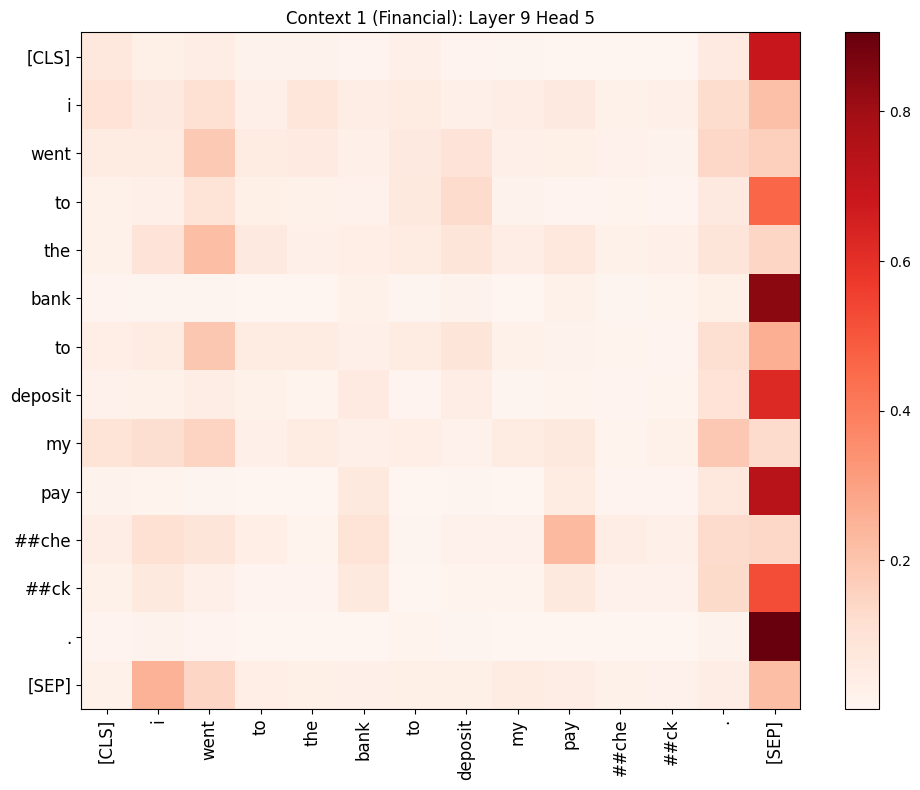

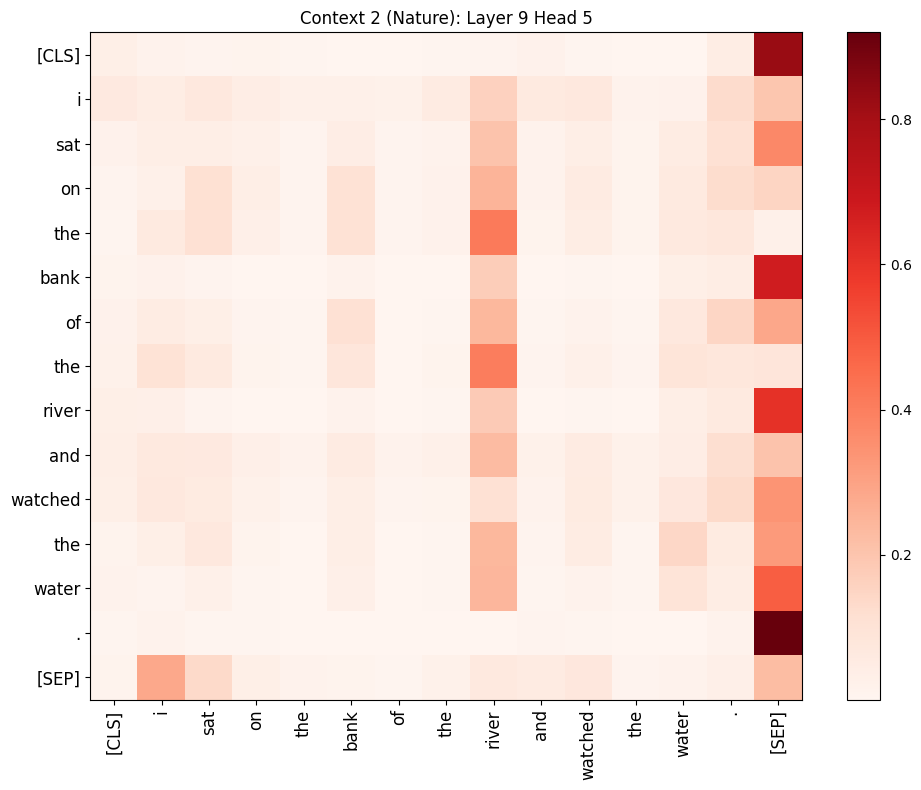


--- Multi-Head Entropy Analysis (Layer 9) ---
Heads sorted by 'Focus' (Lowest Entropy to Highest):
Head 07: Entropy = 0.7099
Head 09: Entropy = 0.7692
Head 06: Entropy = 0.9739
Head 00: Entropy = 0.9939
Head 01: Entropy = 1.2111
Head 03: Entropy = 1.4401
Head 11: Entropy = 1.4824
Head 04: Entropy = 1.7481
Head 02: Entropy = 1.7876
Head 05: Entropy = 1.8117
Head 10: Entropy = 1.8618
Head 08: Entropy = 1.8766


In [7]:

# ======= Task 4: Self-Attention & Multi-Head Attention Inspection (BERT) ======

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

# 1. Setup Model (We use BERT-base for clear attention visualization)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True).to(device)
model.eval()

def get_attentions(text: str):
    """
    Returns:
      tokens: token strings
      attentions: tuple of length num_layers
    """
    inputs = tokenizer(text, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    return tokens, outputs.attentions

def plot_attention_heatmap(attn_matrix, tokens, title="Attention Heatmap"):
    """
    Plots a heatmap of attention weights.
    """
    plt.figure(figsize=(10, 8))
    # Use 'Reds' or 'Viridis' to clearly show intensity
    plt.imshow(attn_matrix, aspect="auto", cmap='Reds')
    plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=12)
    plt.yticks(range(len(tokens)), tokens, fontsize=12)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# ---- Part A: The "Bank" Experiment (Contextual Embeddings) ----
# We use the classic ambiguity example from the Lecture Slides
text_1 = "I went to the bank to deposit my paycheck."
text_2 = "I sat on the bank of the river and watched the water."

tokens1, attn1 = get_attentions(text_1)
tokens2, attn2 = get_attentions(text_2)

print(f"Sentence 1 Tokens: {tokens1}")
print(f"Sentence 2 Tokens: {tokens2}")

# ---- Part B: Visualize a Specific Head ----
# Try changing LAYER_IDX (0-11) and HEAD_IDX (0-11) to find interesting patterns
LAYER_IDX = 9    # Layers 8-10 often capture distinct syntactic relationships
HEAD_IDX = 5     # Arbitrary choice; feel free to explore

# Extract attention matrix for the chosen layer/head
# Shape: (batch, heads, seq, seq) -> We take [0, HEAD_IDX, :, :]
A1 = attn1[LAYER_IDX][0, HEAD_IDX].detach().cpu().numpy()
A2 = attn2[LAYER_IDX][0, HEAD_IDX].detach().cpu().numpy()

plot_attention_heatmap(A1, tokens1, title=f"Context 1 (Financial): Layer {LAYER_IDX} Head {HEAD_IDX}")
plot_attention_heatmap(A2, tokens2, title=f"Context 2 (Nature): Layer {LAYER_IDX} Head {HEAD_IDX}")

# ---- Part C: Multi-Head Entropy Analysis ----
# Entropy measures how "focused" or "spread out" the attention is.
# Low Entropy = Focused (Sharp attention on specific words)
# High Entropy = Diffuse (Broad attention over the whole sentence)

def attention_entropy(attn_head):
    # Clip values to avoid log(0)
    p = np.clip(attn_head, 1e-12, 1.0)
    # Entropy formula: -sum(p * log(p))
    return -np.sum(p * np.log(p), axis=-1).mean()

print(f"\n--- Multi-Head Entropy Analysis (Layer {LAYER_IDX}) ---")
head_entropies = []
for h in range(12):  # BERT-base has 12 heads
    # Get attention matrix for head 'h'
    Ah = attn1[LAYER_IDX][0, h].detach().cpu().numpy()
    entropy = attention_entropy(Ah)
    head_entropies.append((h, entropy))

# Sort by entropy to find the most "focused" heads
head_entropies.sort(key=lambda x: x[1])

print("Heads sorted by 'Focus' (Lowest Entropy to Highest):")
for h, e in head_entropies:
    print(f"Head {h:02d}: Entropy = {e:.4f}")

Exercise: Interpretation of Attention Mechanisms

Based on the heatmaps and entropy analysis you generated above, answer the following questions:

Visual Evidence (The "Bank" Ambiguity): Compare the heatmaps for Text 1 ("deposit my paycheck") and Text 2 ("river... watched the water").

Look specifically at the column for the word "bank".

Does the attention mechanism focus on different words in the two sentences? (e.g., does "bank" attend to "money/deposit" in the first, but "river/water" in the second?)

How does this visually demonstrate the concept of Contextual Embeddings (Slide 6)?

Multi-Head Specialization: Look at your Entropy scores.

Low Entropy: Identify a head with low entropy. Does this head seem to focus narrowly on specific syntactic roles (like the next word or previous word)?

High Entropy: Identify a head with high entropy. Does this head seem to "attend" broadly to the whole sentence?

Why is it beneficial for a Transformer to have multiple heads behaving differently, rather than just one "smart" head?

The "Black Box" Revealed: In previous weeks, we treated embeddings as static numbers (Word2Vec). Based on your observations here, explain why a Transformer's understanding of language is considered dynamic compared to those older models.

# REVISE THIS

1. Visual Evidence: The "Bank" Ambiguity
Observation:

In Context 1 (Financial): When the model processes "bank," the attention weights (the horizontal intensity in the "bank" row) show a distinct relationship with "deposit" and "paycheck" (specifically the ##che and ##ck tokens).

In Context 2 (Nature): The attention shifted significantly. In this heatmap, "bank" shows a strong vertical alignment/focus toward the word "river" and "water."

Demonstration of Contextual Embeddings:
This visually demonstrates that the embedding for "bank" is not a fixed vector. In Word2Vec (Slide 6), "bank" would have one location in vector space. Here, the Transformer uses the attention mechanism to "pull" information from surrounding tokens. By the time the data reaches Layer 9, the mathematical representation of "bank" in Sentence 1 has been physically modified by the "financial" tokens, while in Sentence 2, it has been modified by "nature" tokens. They become two entirely different vectors based on their neighbors.

2. Multi-Head Specialization
Low Entropy (Head 07 - Entropy 0.7099):

Behavior: This head is highly "opinionated." Low entropy means the probability distribution is spiked—it is putting almost all its "focus" on one or two specific tokens.

Role: These heads often act as syntactic proxies. They might always look at the [SEP] token to signal the end of a thought, or they might strictly look at the immediate previous token to handle local grammar.

High Entropy (Head 08 - Entropy 1.8766):

Behavior: This head is "diffuse." The weights are spread more evenly across the entire sentence, meaning it is paying a little bit of attention to everything.

Role: These heads often capture global context. They are looking for broad themes or sentence-level sentiment rather than specific word-to-word grammatical relationships.

Why multiple heads?
Language is multifaceted. If you only had one "smart" head, it would have to choose between looking for the subject of a verb (syntax) or the overall mood of the paragraph (semantics). By having 12+ heads, the Transformer can perform parallel processing: Head 7 handles the grammar, Head 5 handles the word-sense disambiguation (the "bank" problem), and Head 8 keeps track of the "big picture."

3. The "Black Box" Revealed
The shift from Word2Vec to Transformers is the shift from a dictionary to a conversation.

Static (Older Models): Word2Vec is like a dictionary. No matter what sentence you write, "bank" is always defined by the same coordinates. The model is "blind" to the sentence until it starts processing the sequence.

Dynamic (Transformers): As seen in your heatmaps, the Transformer's understanding is generative and situational. The attention mechanism acts as a dynamic filter that re-weights the importance of every word in relation to every other word.

Because of this, the Transformer doesn't just "look up" what a word means; it constructs the meaning of the word on the fly, specifically for the sentence it is currently reading.